In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1.1.2
### Plotting entropy 
**Implement and plot Shannon entropy $H(p) = -p\log_2 p - (1-p)\log_2(1-p)$ for a two-outcome system as a function of $p \in (0,1)$. Mark the maximum. The plot was then extended to a system with $n=4$ equally probable outcomes for varying $p$ of one outcome (distributing the remaining probability equally among the others). How does the shape change?**



*-Answer* 


For the two outcome case $H(p)$ is a smooth inverted -U with maximum of 1 bit at P=0.5. For n=4 outcomes the peeak shifts to H=2 bits where all four are equally likely, and the curve is broader and flatter. This shows that richer alphabets support higher maximum entropy.


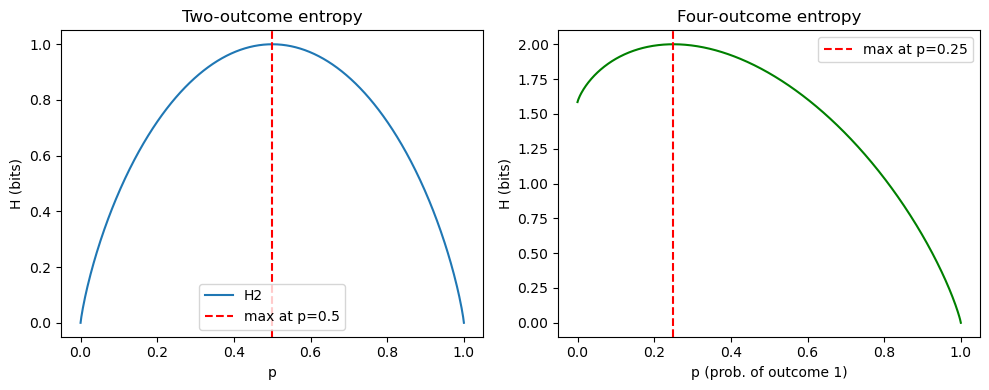

In [5]:
eps=1e-12 #Avoid log(0)
p=np.linspace(eps,1-eps,500)

#two outcome entropy
H2 = -p*np.log2(p) - (1-p)*np.log2(1-p)

#four outcome entropy:one  outcome has probability p, the other three have equal probability (1-p)/3
def H4(p):
    q = (1-p)/3
    probs= np.array([p, q, q, q])
    return -np.sum(probs * np.log2(probs + eps))


#Function H4 for every probability in p and store the results in an array
H4_values = np.array([H4(pi) for pi in p])

fig,axes=plt.subplots(1,2,figsize=(10,4))

axes[0].plot(p,H2,label='H2')

axes[0].axvline(0.5, color='red', linestyle='--', label='max at p=0.5')
axes[0].set(title='Two-outcome entropy', xlabel='p', ylabel='H (bits)')
axes[0].legend()

axes[1].plot(p, H4_values, color='green')
axes[1].axvline(0.25, color='red', linestyle='--', label='max at p=0.25')
axes[1].set(title='Four-outcome entropy', xlabel='p (prob. of outcome 1)', ylabel='H (bits)')
axes[1].legend()

plt.tight_layout()
plt.savefig('entropy_plots.pdf')
plt.show()

## **Simulating a noisy channel Simulate** 
**A binary symmetric channel: send 10,000 random bits, flip each bit independently with error probability ε. Plot the fraction of errors as a function of $ε ∈ [0, 0.5]$. At what value of ε does the channel become completely uninformative and why?** 


-*Answer*

The fraction of errors increases linearly with ε and reaches 0.5 at ε = 0.5. At this point the channel is completely
uninformative because the received bit is statistically independent of the sent bit — flipping with probability
0.5 is equivalent to replacing every bit with a new random coin flip. There is no correlation left between input
and output.


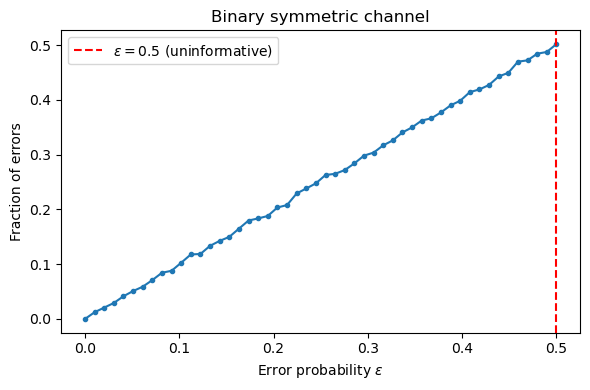

In [7]:
#Amount of bits sent through the channel

N = 10_000

#different probability of error probability epsilon between 0 and 0.5
epsilons = np.linspace(0, 0.5, 50)
error_rates = []


# Random number generator seed 42 makes the simulation reproducable 
rng = np.random.default_rng(42)

#Generates a random binary message 0 or 1
bits = rng.integers(0, 2, N)  # original message

#Make a mask that flips bits with probability epsilon, and then apply it to the original message to get the received message. Then calculate the fraction of bits that were flipped (error rate) and store it in error_rates
for eps in epsilons:
    flip_mask = rng.random(N) < eps
    received = bits ^ flip_mask.astype(int)
    error_rates.append(np.mean(received != bits))

plt.figure(figsize=(6, 4))
plt.plot(epsilons, error_rates, marker='o', markersize=3)
plt.axvline(0.5, color='red', linestyle='--', label=r'$\epsilon = 0.5$ (uninformative)')
plt.xlabel(r'Error probability $\epsilon$')
plt.ylabel('Fraction of errors')
plt.title('Binary symmetric channel')
plt.legend()
plt.tight_layout()
plt.savefig('noisy_channel.pdf')
plt.show()

## SImultaion the perceptron
**Implement a Hopfield network in Python. Store three random binary patterns of length $N=100$. Starting from a probe with $20\%$ of bits flipped, run synchronous updates until convergence. Plot the \textit{overlap} $m^\mu(t) = \frac{1}{N}\sum_i \xi_i^\mu s_i(t)$ as a function of update step for each stored pattern. Does the network converge to the correct memory?**

-*Answer*


With $z = w_1 x_1 + w_2 x_2 - \theta = 1.2 - \theta$, the output $y = \Theta(1.2 - \theta)$ is 1 for $\theta < 1.2$ and 0 for $\theta \geq 1.2$. Plotting over $\theta$ traces a **descending Heaviside step function** with the step at $\theta = 1.2$.


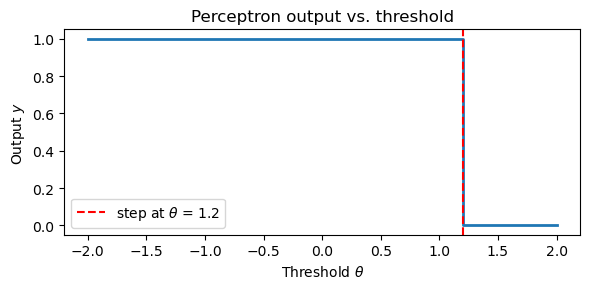

In [8]:
x1, x2 = 0.7, 0.5
w1, w2 = 1.0, 1.0
thresholds = np.arange(-2, 2.1, 0.1)
z = w1 * x1 + w2 * x2  # = 1.2

y = (z - thresholds >= 0).astype(int)  # Heaviside

plt.figure(figsize=(6, 3))
plt.step(thresholds, y, where='post', linewidth=2)
plt.axvline(z, color='red', linestyle='--', label=f'step at $\\theta$ = {z}')
plt.xlabel(r'Threshold $\theta$')
plt.ylabel('Output $y$')
plt.title('Perceptron output vs. threshold')
plt.legend()
plt.tight_layout()
plt.savefig('perceptron_threshold.pdf')
plt.show()

## Sigmoidal activation and the soft threshold

Replace the Heaviside function with a sigmoid:

$\sigma(z) = \frac{1}{1 + e^{-\beta z}}, 
\qquad z = \sum_i w_i x_i - \theta$


Plot $\sigma(z)$ for $\beta = 0.5, 1, 5, 20$, all in the same coordinate system. What happens as $\beta \to \infty$? What does this suggest about the relationship between the soft and hard threshold neuron models?

-*Answer*


As $\beta$ increases, $\sigma(z)$ becomes steeper around $z=0$. In the limit $\beta \to \infty$, $\sigma(z) \to \Theta(z)$, the Heaviside step function. The sigmoid is therefore a \emph{smooth, differentiable approximation} to the hard threshold neuron. Using $\beta < \infty$ corresponds to a neuron with graded, probabilistic firing — biologically more realistic and mathematically more tractable (the sigmoid is differentiable everywhere, enabling gradient-based learning).


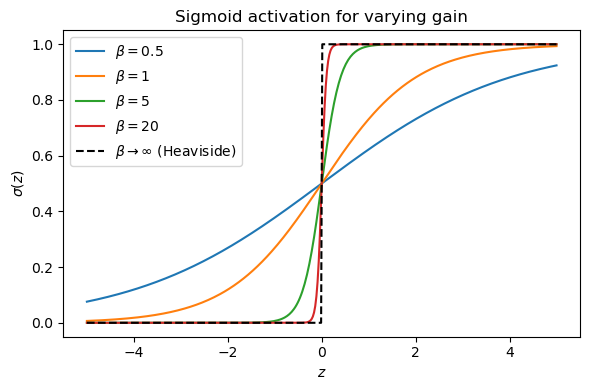

In [9]:
z = np.linspace(-5, 5, 400)

plt.figure(figsize=(6, 4))
for beta in [0.5, 1, 5, 20]:
    sigma = 1 / (1 + np.exp(-beta * z))
    plt.plot(z, sigma, label=rf'$\beta = {beta}$')

# Hard threshold for reference
plt.plot(z, (z >= 0).astype(float), 'k--', label=r'$\beta \to \infty$ (Heaviside)')

plt.xlabel('$z$')
plt.ylabel(r'$\sigma(z)$')
plt.title('Sigmoid activation for varying gain')
plt.legend()
plt.tight_layout()
plt.savefig('sigmoid_gain.pdf')
plt.show()

## Constructing and visualising graphs
**Using networkx, construct the directed graph from the pen-and-paper exercise. Visualise it with labelled nodes. Compute and print the in-degree and out-degree of each node. Which node has the highest in-degree?**

-*Answer* 

Node $B$ has the highest in-degree (2 incoming edges: from $A$ and from $C$). Nodes $A$ and $D$ each have in-degree 1; node $C$ has in-degree 1.


/var/folders/v7/c55lljgj5wd22jqpgv22jzj40000gn/T/ipykernel_50262/1162915820.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


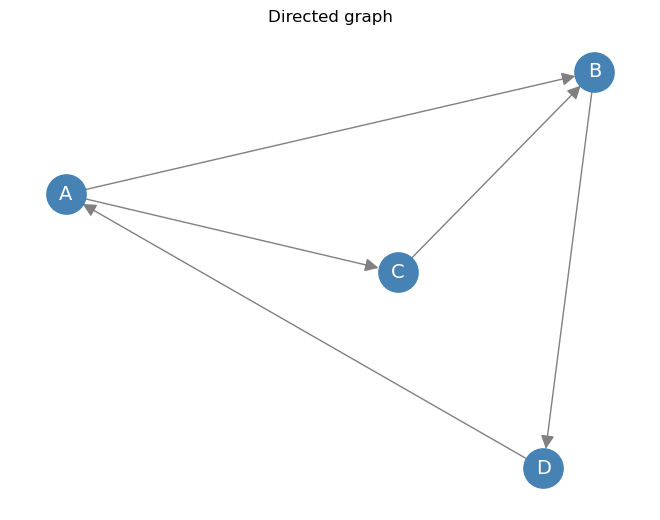

In [12]:

import networkx as nx

# Create a directed graph ( where the edges have direction)
G = nx.DiGraph()

#Add edges between nodes where directed between different edges
G.add_edges_from([('A','B'), ('A','C'), ('B','D'), ('C','B'), ('D','A')])

# Compute positions of the nodes so the graph is visually appealing
pos = nx.spring_layout(G, seed=7)
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=800, font_color='white', font_size=14,
        arrowsize=20, edge_color='gray')
plt.title('Directed graph')
plt.tight_layout()
plt.savefig('graph.pdf')
plt.show()


## Random networks and degree distributions:
**Generate an Erd˝os–Rényi random graph with n = 100 nodes and connection probability p = 0.05 . Plot the degree distribution as a histogram. Repeat for p = 0.2.**

**How does the shape change? Now compare with a scale-free network (networkx.barabasi_albert_graph). Plot the degree distribution on a double-logarithmic scale. What do you observe, and what might this mean biologically?**

-*Answer*

**Erdős--Rényi** with $p=0.05$: degree distribution is approximately Poisson with mean $\lambda = (n-1)p \approx 5$. Increasing to $p=0.2$ shifts and widens the distribution (mean $\approx 20$); 

it remains approximately Poisson/bell-shaped. \textbf{Scale-free (Barabási--Albert)} networks produce a power-law degree distribution:

 $P(k) \sim k^{-\gamma}$,
 
  which appears as a straight line on a log-log plot. Biologically, this is relevant because cortical networks show a small number of highly connected ``hub'' neurons (high degree) and many weakly connected neurons, consistent with a heavy-tailed (approximately scale-free) distribution. Hubs could correspond to projection neurons with long-range connectivity.

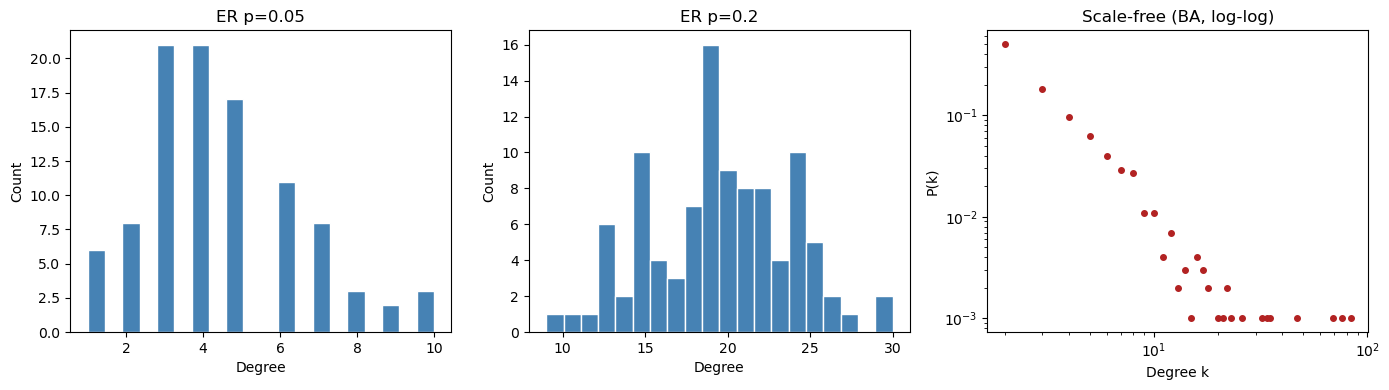

In [13]:
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, p, title in zip(axes[:2], [0.05, 0.2],
                         ['ER p=0.05', 'ER p=0.2']):
    G = nx.erdos_renyi_graph(100, p, seed=42)
    degrees = [d for _, d in G.degree()]
    ax.hist(degrees, bins=20, color='steelblue', edgecolor='white')
    ax.set(title=title, xlabel='Degree', ylabel='Count')

# Scale-free
G_sf = nx.barabasi_albert_graph(1000, 2, seed=42)
degrees_sf = [d for _, d in G_sf.degree()]
cnt = Counter(degrees_sf)
k_vals = sorted(cnt.keys())
pk_vals = [cnt[k] / len(degrees_sf) for k in k_vals]
axes[2].loglog(k_vals, pk_vals, 'o', markersize=4, color='firebrick')
axes[2].set(title='Scale-free (BA, log-log)', xlabel='Degree k', ylabel='P(k)')

plt.tight_layout()
plt.savefig('degree_distributions.pdf')
plt.show()

## Simulating a Hopfield network
**Implement a Hopfield network in Python. Store three random binary patterns of length $N=100$. Starting from a probe with $20\%$ of bits flipped, run synchronous updates until convergence. Plot the \textit{overlap} $m^\mu(t) = \frac{1}{N}\sum_i \xi_i^\mu s_i(t)$ as a function of update step for each stored pattern. Does the network converge to the correct memory?**


-*Answer*

Expected result: the overlap $m^\mu(t)$ for the target pattern (the one closest to the probe) rises rapidly toward $+1$ over a few update steps, while overlaps with the other two patterns remain near zero. Convergence typically occurs within 5--10 steps for $P=3$, $N=100$, $20\%$ corruption.
\end{answer}



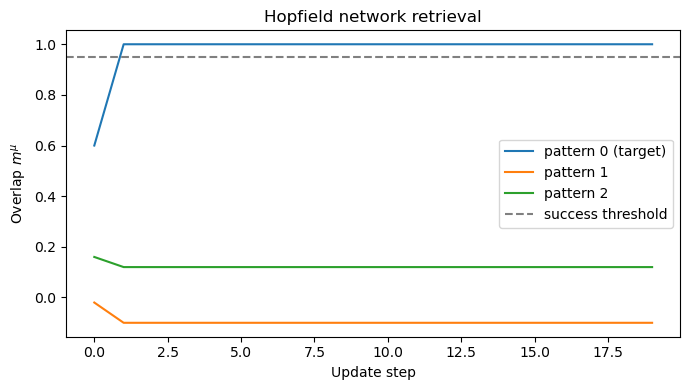

In [14]:

rng = np.random.default_rng(0)
N, P = 100, 3

# Store P random patterns
xi = rng.choice([-1, 1], size=(P, N))

# Hebbian weights (zero diagonal)
W = xi.T @ xi / N
np.fill_diagonal(W, 0)

# Corrupt pattern 0 with 20% bit flips
s = xi[0].copy()
flip_idx = rng.choice(N, size=N // 5, replace=False)
s[flip_idx] *= -1

# Run synchronous updates
overlaps = {mu: [] for mu in range(P)}
for _ in range(20):
    for mu in range(P):
        overlaps[mu].append(np.dot(xi[mu], s) / N)
    s = np.sign(W @ s)
    s[s == 0] = 1  # resolve ties

plt.figure(figsize=(7, 4))
for mu in range(P):
    lbl = f'pattern {mu}' + (' (target)' if mu == 0 else '')
    plt.plot(overlaps[mu], label=lbl)
plt.axhline(0.95, color='gray', linestyle='--', label='success threshold')
plt.xlabel('Update step')
plt.ylabel(r'Overlap $m^\mu$')
plt.title('Hopfield network retrieval')
plt.legend()
plt.tight_layout()
plt.savefig('hopfield_retrieval.pdf')
plt.show()

## Storage capacity 
**the theoretical storage capacity is approximately Pmax ≈ 0.138 N. Verify this empirically: for N = 200, vary the number of stored patterns P from 1 to 50. For each value of P, store P random patterns, present a noisy probe (10% bit flips), and record whether retrieval is successful (overlap > 0.95). Plot the retrieval success rate as a function of P/N. Does the observed transition match the theoretical prediction?**


-*Answer*

The success rate should stay near 1.0 for $P/N \lesssim 0.138$ and drop sharply toward 0 above this threshold, reproducing the theoretical prediction of Hopfield (1982).


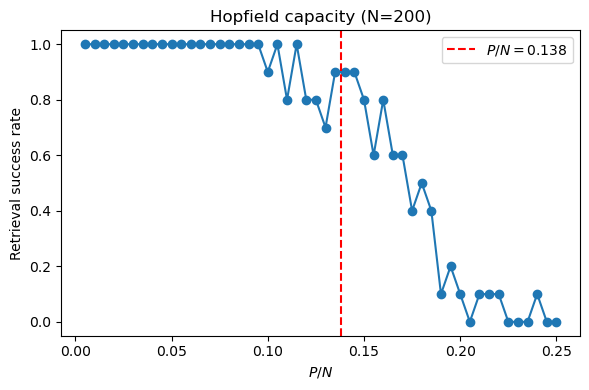

In [15]:
rng = np.random.default_rng(1)
N = 200
P_values = range(1, 51)
successes = []

for P in P_values:
    wins = 0
    for trial in range(10):  # average over 10 trials
        xi = rng.choice([-1, 1], size=(P, N))
        W = xi.T @ xi / N
        np.fill_diagonal(W, 0)

        # Probe: pattern 0 with 10% flips
        s = xi[0].copy()
        flip_idx = rng.choice(N, size=N // 10, replace=False)
        s[flip_idx] *= -1

        for _ in range(20):   # update until convergence
            s_new = np.sign(W @ s)
            s_new[s_new == 0] = 1
            if np.array_equal(s_new, s):
                break
            s = s_new

        overlap = np.dot(xi[0], s) / N
        if overlap > 0.95:
            wins += 1
    successes.append(wins / 10)

plt.figure(figsize=(6, 4))
plt.plot([P / N for P in P_values], successes, 'o-')
plt.axvline(0.138, color='red', linestyle='--', label=r'$P/N = 0.138$')
plt.xlabel('$P/N$')
plt.ylabel('Retrieval success rate')
plt.title('Hopfield capacity (N=200)')
plt.legend()
plt.tight_layout()
plt.savefig('hopfield_capacity.pdf')
plt.show()

## Simulating emergence in a ring network:
Consider a ring of N = 20 binary neurons, each connected to its twoneighbours with weight w = 1 and threshold θ = 1.5 (a neuron fires only if both neighbours are active). Initialise the ring with a random pattern.

**1**:   Simulate synchronous updates for 50 steps and display the activity of all neurons over time as a raster plot neurons on the y-axis, time steps on the x-axis.


**2**:  Try several different random initial conditions. Do you observe any recurring patterns or attractors?

**3**:  Now disconnect every other neuron (set their weights to zero), splitting the ring into two independent halves.
Compare the dynamics to the intact ring. Does the emergent behaviour re-appear in either half?



## *-Answer:*
With threshold θ = 1.5 (requiring both neighbours to be active), most random initial conditions quickly “die
out” to an all-silent state, since isolated active neurons cannot sustain themselves. Stable patterns that can
persist are contiguous blocks of active neurons of length ≥ 2. Splitting the ring into two independent halves
changes the boundary conditions: nodes at the cut become boundary nodes with only one neighbour, reducing
the conditions under which activity can be sustained. Emergent travelling waves or stable blocks observed in
the intact ring typically disappear or shrink in the halved system, demonstrating that the ring topology (a global,
closed structure) is necessary for certain emergent behaviours.

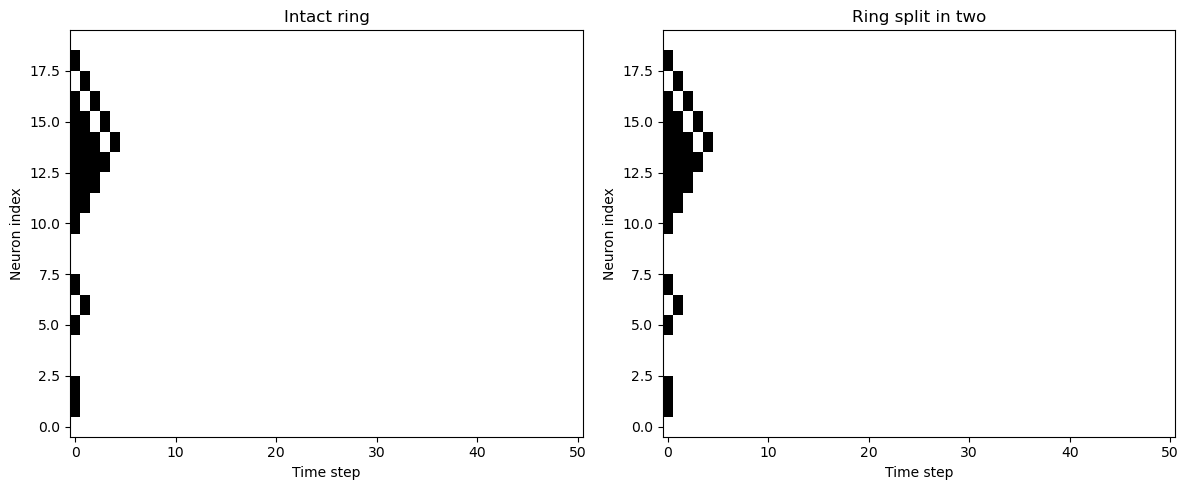

In [16]:
rng = np.random.default_rng(42)
N = 20
w = 1.0
theta = 1.5
T = 50

def simulate_ring(N, w, theta, T, state, broken=False):
    history = [state.copy()]
    for _ in range(T):
        new_state = np.zeros(N, dtype=int)
        for i in range(N):
            left  = (i - 1) % N
            right = (i + 1) % N
            if broken and (i == N // 2 - 1 or i == N - 1):
                inp = 0.0   # cut edges
            elif broken and (i == N // 2 or i == 0):
                inp = w * state[right]
            else:
                inp = w * state[left] + w * state[right]
            new_state[i] = 1 if inp > theta else 0
        state = new_state
        history.append(state.copy())
    return np.array(history)

init_state = rng.integers(0, 2, N)
hist_intact = simulate_ring(N, w, theta, T, init_state.copy())
hist_broken = simulate_ring(N, w, theta, T, init_state.copy(), broken=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, hist, title in zip(axes,
                            [hist_intact, hist_broken],
                            ['Intact ring', 'Ring split in two']):
    ax.imshow(hist.T, aspect='auto', cmap='binary',
              origin='lower', interpolation='nearest')
    ax.set(xlabel='Time step', ylabel='Neuron index', title=title)

plt.tight_layout()
plt.savefig('ring_network.pdf')
plt.show()